In [1]:
from pinnsform import *
from pinnsform.model import PINNsformer, PINNsformerNoAttention
import matplotlib.pyplot as plt

def load_csv_to_numpy(file_path):
    df = pd.read_csv(file_path, header=None, index_col=None, sep=",")
    return np.array(df.values)

def visualize_solution(model, mesh, mesh_shape, domain):
    prediction = f(model, mesh)[:,0].detach().cpu().numpy()
    predicted_mesh = np.reshape(prediction, mesh_shape)
    #[0,np.pi*2,1,0]
    plt.figure(figsize=(8,6))
    domain_extend = [domain[1][0], domain[1][1], domain[0][0], domain[0][1]]
    plt.imshow(predicted_mesh, extent=domain_extend, aspect='auto')
    plt.xlabel('t')
    plt.ylabel('x')
    plt.title('Predicted u(x,t)')
    plt.colorbar()
    plt.tight_layout()
    #plt.savefig('./1dreaction_pinnsformer_pred.png')
    plt.show()
    return predicted_mesh

def intial_value_function(x):
    return torch.exp(- (x - torch.pi)**2 / (2*(torch.pi/4.0)**2))

In [3]:
device = 'cuda'

NUM_SEEDS = 100
INIT_SEEDS = np.array(range(NUM_SEEDS))

problem_domain = ([0, 2*np.pi], [0, 1])
train_points = (51, 51)

sequence_mesh, sequence_boundaries = generate_mesh_object(train_points, domain=problem_domain, device=device, full_requires_grad=True, border_requires_grad=False, num_seq_steps=5, seq_step_size=1e-3)
b_left_seq = sequence_boundaries[0][0]
b_right_seq = sequence_boundaries[0][1]
initial_seq = sequence_boundaries[1][0]

with torch.no_grad():
    initial_values = intial_value_function(initial_seq.part[0][:,0])   #torch.exp(- (x_left[:,0] - torch.pi)**2 / (2*(torch.pi/4)**2))


In [4]:

train_points = (51, 51)

# 51 x 51 mesh
np_mesh = generate_mesh(train_points, problem_domain)
# create spatial sequences
np_sequence_mesh = make_temporal_sequence(np_mesh, 5, 1e-3)
# flatten the sequence
np_sequence_mesh = np.expand_dims(listify_sequence(np_sequence_mesh), 1)
# make torch Mesh object and borders
single_mesh = torchify(np_sequence_mesh, device, True)
single_boundaries = torchified_borders(np_sequence_mesh, problem_domain, device, False)

b_left_sing = single_boundaries[0][0]
b_right_sing = single_boundaries[0][1]
initial_sing = single_boundaries[1][0]


#with torch.no_grad():
#    initial_values = intial_value_function(initial_sing.part[0][:,0])

In [35]:
base_dir = os.getcwd()
experiment_name = "PINNFORMER_VAR_TS_LBFGS_200" #"PINNFORMER_NoSequence"#"PINNFORMER_TS"
model_name = "PINNsformer"
path = os.path.join(base_dir, 'results', experiment_name, 'run', model_name)
#init_path = os.path.join(base_dir, 'results', experiment_name, 'InitWeights')
#error_path = os.path.join(base_dir, 'results', experiment_name, '51mesh')

In [36]:
rmae_list = []
for i in INIT_SEEDS:
    rmae_path = os.path.join(path, f"seed_{i}", "error.csv")
    data = load_csv_to_numpy(rmae_path)
    rmae_list.append(float(data[1,0]))

In [37]:
sum(np.array(rmae_list) > 0.5)

6

In [38]:
mesh = sequence_mesh

mean_init_values = []
mean_abs_dfx = []
mean_abs_dft = []
mean_t0_values = []
mean_t0_residues = []


def mean_init_prediction(model, mesh):
    return np.mean(f(model, mesh).detach().cpu().numpy())



for i in INIT_SEEDS:
    weight_path = os.path.join(path, f"seed_{i}", "model_at_0.pth")
    model = PINNsformer(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device)
    model.load_state_dict(torch.load(weight_path))
    pred = f(model, mesh).detach().cpu().numpy()
    #dfx = df(model, mesh, wrt=0).detach().cpu().numpy()
    #dft = df(model, mesh, wrt=1).detach().cpu().numpy()
    #mean_t0_values.append(np.mean(f(model, initial)[:,0].detach().cpu().numpy()))
    #mean_t0_residues.append(np.mean((f(model, initial)[:,0] - initial_values).detach().cpu().numpy()))
    #mean_abs_dfx.append(np.mean(dfx))
    #mean_abs_dft.append(np.mean(dft))
    mean_init_values.append(np.mean(pred))

In [39]:
init_error_stack = np.stack([INIT_SEEDS, mean_init_values, rmae_list], axis=1)
print("seed\tmiv\tmdft\trmae")
for entry in init_error_stack[init_error_stack[:,1].argsort()]:
    print(f"{entry[0]}\t{entry[1]}\t{entry[2]}")#\t{entry[3]}\t{entry[4]}\t{entry[5]}\t{entry[6]}")

seed	miv	mdft	rmae
44.0	-2.660696506500244	0.028333526
13.0	-2.5707054138183594	0.014452601
73.0	-2.5510456562042236	0.023802664
89.0	-2.395913600921631	0.05699887
30.0	-2.253397226333618	0.052313805
74.0	-2.2533366680145264	0.038666915
85.0	-2.210542917251587	0.96834236
96.0	-1.9065431356430054	0.03035575
33.0	-1.8648626804351807	0.027235312
4.0	-1.8040263652801514	0.012609222
17.0	-1.7488278150558472	0.023027226
6.0	-1.597090482711792	0.01801588
75.0	-1.5531072616577148	0.031544473
49.0	-1.4646632671356201	0.028101837
11.0	-1.4392015933990479	0.025383359
83.0	-1.4166189432144165	0.04183898
81.0	-1.4121174812316895	0.9846781
46.0	-1.3953745365142822	0.017827068
32.0	-1.3291089534759521	0.023262542
91.0	-1.2475738525390625	0.073668964
76.0	-1.1374361515045166	0.020899422
86.0	-1.0643432140350342	0.028724106
48.0	-1.027698278427124	0.011688129
99.0	-1.0233370065689087	0.97947186
27.0	-0.9899164438247681	0.033420965
47.0	-0.9644696712493896	0.026419463
10.0	-0.9518020153045654	0.9841923


In [40]:
analysis_path = os.path.join(base_dir, "analysis", experiment_name)

In [42]:
data_stack = np.stack([INIT_SEEDS, mean_init_values, rmae_list], axis=1)
data_stack = data_stack[data_stack[:,1].argsort()]
pd.DataFrame(data_stack, columns=["init_seed", "mean_init_value", "rMAE"]).to_csv(os.path.join(analysis_path, "MIVrMAE_PINNsformer_.csv"), index = False)

In [6]:
base_dir = os.getcwd()
experiment_name = "SixModels_32Bit_LBFGS_TS"
trained_path = os.path.join(base_dir, 'results', experiment_name, '51mesh', 'seed_1', 'trained_model.pth')
init_path = os.path.join(base_dir, 'results', experiment_name, 'InitWeights', 'seed_1', 'init_model.pth')
init_tanh_path = os.path.join(base_dir, 'results', experiment_name, '20240924_120425', 'seed_1', 'init_model.pth')
trained_tanh_path = os.path.join(base_dir, 'results', experiment_name, '20240924_120425', 'seed_1', 'trained_model.pth')

In [40]:
trained_model.load_state_dict(torch.load(trained_path))
init_model.load_state_dict(torch.load(init_path))
init_model_tanh.load_state_dict(torch.load(init_tanh_path))
trained_model_tanh.load_state_dict(torch.load(trained_tanh_path))

<All keys matched successfully>

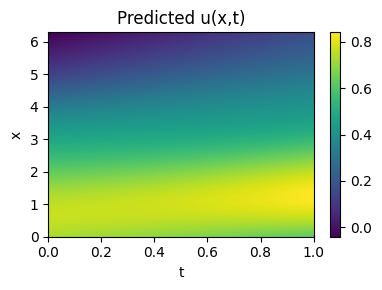

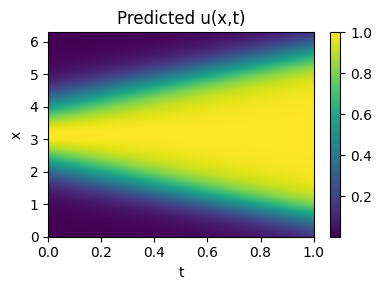

array([[0.00098121, 0.00103203, 0.00108416, ..., 0.15738767, 0.16075338,
        0.16417487],
       [0.00112174, 0.00116709, 0.00121334, ..., 0.16975538, 0.17332467,
        0.17695001],
       [0.00127633, 0.00131623, 0.00135866, ..., 0.18292876, 0.18670574,
        0.19054295],
       ...,
       [0.0018441 , 0.00186048, 0.00188168, ..., 0.17788975, 0.18155563,
        0.1852812 ],
       [0.00173618, 0.00174551, 0.0017587 , ..., 0.16724032, 0.17073208,
        0.17428078],
       [0.00162305, 0.00162685, 0.00163425, ..., 0.15739806, 0.16072454,
        0.16410385]], dtype=float32)

In [42]:
visualize_solution(init_model, test_mesh, test_points, problem_domain)
visualize_solution(trained_model, test_mesh, test_points, problem_domain)

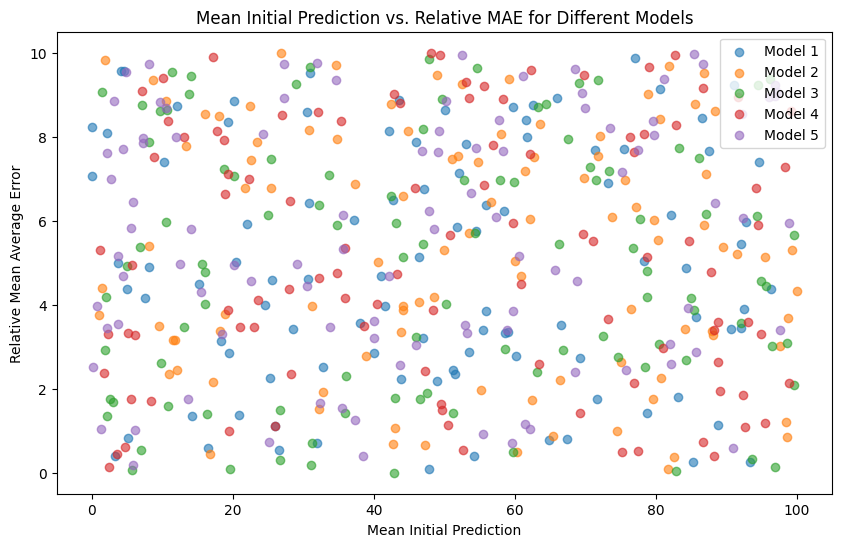

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data for K models, each with 100 runs
K = 5  # number of models
runs = 100  # number of runs per model

# Generate random sample data
mean_initial_prediction = np.random.rand(K, runs) * 100  # example data for initial predictions
relative_mae = np.random.rand(K, runs) * 10  # example data for relative Mean Average Error

# Plot
plt.figure(figsize=(10, 6))
for i in range(K):
    plt.scatter(mean_initial_prediction[i], relative_mae[i], label=f'Model {i+1}', alpha=0.6)

plt.xlabel("Mean Initial Prediction")
plt.ylabel("Relative Mean Average Error")
plt.title("Mean Initial Prediction vs. Relative MAE for Different Models")
plt.legend()
plt.show()